# ADS-502 Team Project — Health/Medical Feature Group
Bereket Tarekegn  
Dataset: LLCP2014.XPT (BRFSS 2014)

This notebook is optimized for **low memory** by loading **only the Health/Medical columns**
from the XPT file using `pyreadstat.read_xport` with a safe encoding.

It covers:
- **Week 1**: Load subset, clean columns, schema, EDA
- **Week 2**: Clean BRFSS codes, create `diabetes_binary`, and train a baseline Logistic Regression model.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyreadstat

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ---------------------------------------------
# Use your exact path (do not change this path)
# ---------------------------------------------
DATA_PATH = r"C:\Users\bezaa\OneDrive\Desktop\USD\ADS-502-01 Applied Data Mining\Project\LLCP2014XPT\LLCP2014.XPT"

# Raw BRFSS column names as they appear in the XPT file (uppercase)
raw_health_medical_cols = [
    "DIABETE3",   # diabetes status
    "BPHIGH4",
    "HIGHCHOL",
    "CHOLCHK",
    "STROKE",
    "CVDCRHD4",
    "BMI5",
    "GENHLTH",
    "MENTHLTH",
    "PHYSHLTH",
    "DIFFWALK",
]

# Load ONLY the needed columns to avoid MemoryError
try:
    df, meta = pyreadstat.read_xport(
        DATA_PATH,
        usecols=raw_health_medical_cols,
        encoding="latin1"
    )
except UnicodeDecodeError:
    df, meta = pyreadstat.read_xport(
        DATA_PATH,
        usecols=raw_health_medical_cols,
        encoding="cp1252"
    )

print("Subset dataset loaded successfully.")
print("Shape (rows, cols):", df.shape)
df.head()

Subset dataset loaded successfully.
Shape (rows, cols): (464664, 6)


,GENHLTH,PHYSHLTH,MENTHLTH,CVDCRHD4,DIABETE3,DIFFWALK
0,5.0,25.0,5.0,2.0,1.0,1.0
1,3.0,7.0,14.0,2.0,3.0,1.0
2,1.0,88.0,88.0,2.0,3.0,2.0
3,3.0,77.0,77.0,2.0,1.0,1.0
4,3.0,2.0,88.0,1.0,3.0,2.0


In [3]:
def clean_columns(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame.columns = (
        frame.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("/", "_")
        .str.replace("-", "_")
    )
    return frame

df = clean_columns(df)

print("Cleaned columns:")
list(df.columns)

Cleaned columns:


['genhlth', 'physhlth', 'menthlth', 'cvdcrhd4', 'diabete3', 'diffwalk']

In [4]:
# After cleaning, expected names are lower case versions
health_medical_cols = [
    "diabete3",   # diabetes status
    "bphigh4",
    "highchol",
    "cholchk",
    "stroke",
    "cvdcrhd4",
    "bmi5",
    "genhlth",
    "menthlth",
    "physhlth",
    "diffwalk",
]

existing_cols = [c for c in health_medical_cols if c in df.columns]
missing_cols = [c for c in health_medical_cols if c not in df.columns]

print("Existing health/medical columns:", existing_cols)
print("Missing health/medical columns:", missing_cols)

df_hm = df[existing_cols].copy()
print("Health/Medical subset shape:", df_hm.shape)
df_hm.head()

Existing health/medical columns: ['diabete3', 'cvdcrhd4', 'genhlth', 'menthlth', 'physhlth', 'diffwalk']
Missing health/medical columns: ['bphigh4', 'highchol', 'cholchk', 'stroke', 'bmi5']
Health/Medical subset shape: (464664, 6)


,diabete3,cvdcrhd4,genhlth,menthlth,physhlth,diffwalk
0,1.0,2.0,5.0,5.0,25.0,1.0
1,3.0,2.0,3.0,14.0,7.0,1.0
2,3.0,2.0,1.0,88.0,88.0,2.0
3,1.0,2.0,3.0,77.0,77.0,1.0
4,3.0,1.0,3.0,88.0,2.0,2.0


In [5]:
print("\nInfo for health/medical subset:")
df_hm.info()

print("\nSummary statistics:")
df_hm.describe().T


Info for health/medical subset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464664 entries, 0 to 464663
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   diabete3  464662 non-null  float64
 1   cvdcrhd4  464664 non-null  float64
 2   genhlth   464660 non-null  float64
 3   menthlth  464663 non-null  float64
 4   physhlth  464660 non-null  float64
 5   diffwalk  448134 non-null  float64
dtypes: float64(6)
memory usage: 21.3 MB

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
diabete3,464662.0,2.752885,0.729478,1.0,3.0,3.0,3.0,9.0
cvdcrhd4,464664.0,1.982762,0.541203,1.0,2.0,2.0,2.0,9.0
genhlth,464660.0,2.578653,1.139014,1.0,2.0,2.0,3.0,9.0
menthlth,464663.0,65.080531,35.660636,1.0,30.0,88.0,88.0,99.0
physhlth,464660.0,61.195235,36.890871,1.0,20.0,88.0,88.0,99.0
diffwalk,448134.0,1.853046,0.585730,1.0,2.0,2.0,2.0,9.0


In [6]:
missing_summary = df_hm.isna().sum().to_frame("missing_count")
missing_summary["missing_percent"] = missing_summary["missing_count"] / len(df_hm) * 100

print("\nMissing value summary (health/medical features):")
missing_summary


Missing value summary (health/medical features):


,missing_count,missing_percent
diabete3,2,0.000430
cvdcrhd4,0,0.000000
genhlth,4,0.000861
menthlth,1,0.000215
physhlth,4,0.000861
diffwalk,16530,3.557409


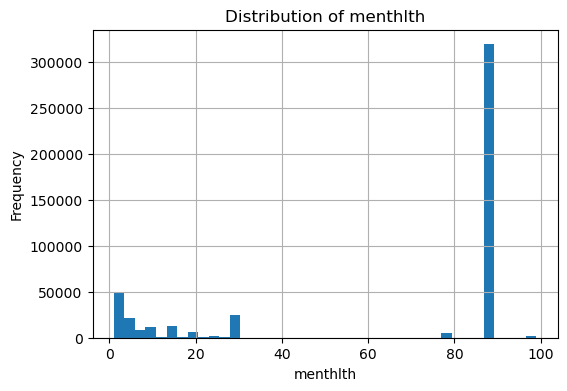

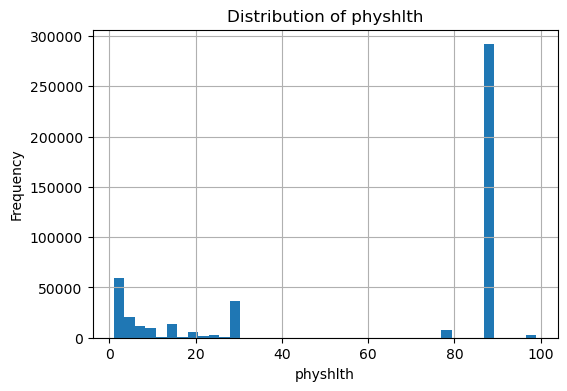

In [7]:
numeric_features = [c for c in ["bmi5", "menthlth", "physhlth"] if c in df_hm.columns]

for col in numeric_features:
    plt.figure(figsize=(6, 4))
    df_hm[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

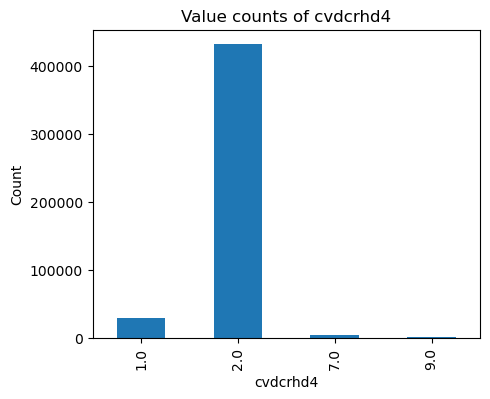

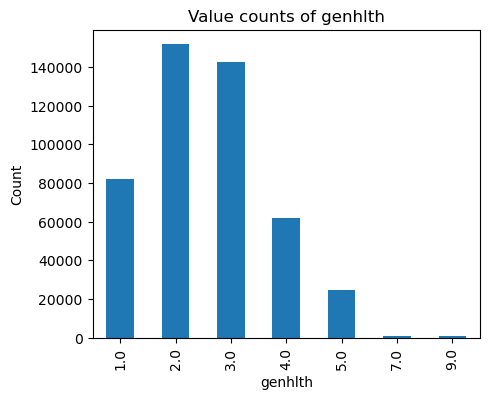

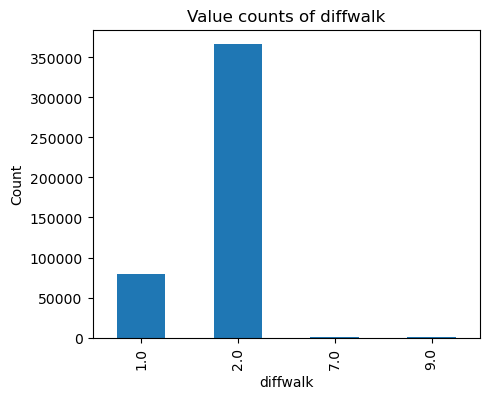

In [8]:
binary_like = [c for c in ["bphigh4", "highchol", "cholchk", "stroke", "cvdcrhd4", "genhlth", "diffwalk"] if c in df_hm.columns]

for col in binary_like:
    plt.figure(figsize=(5, 4))
    df_hm[col].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Value counts of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

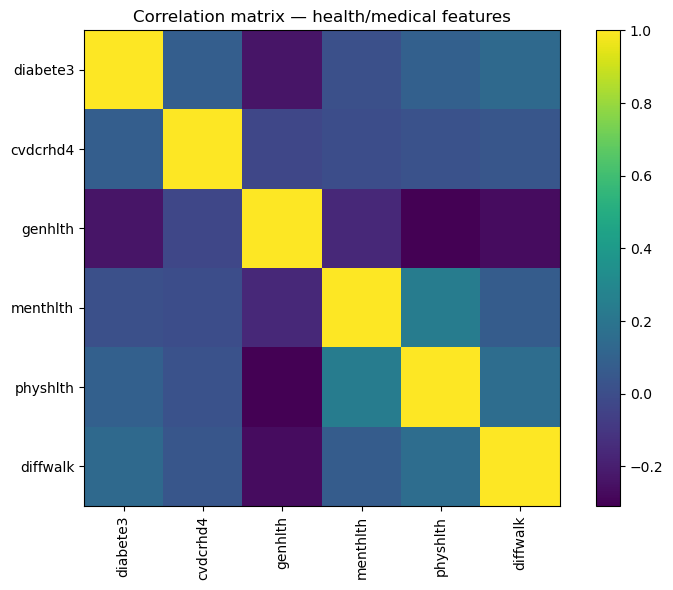

In [9]:
numeric_cols = df_hm.select_dtypes(include=[np.number]).columns

corr_matrix = df_hm[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation matrix — health/medical features")
plt.colorbar()
plt.tight_layout()
plt.show()

In [10]:
output_path_week1 = r"C:\Users\bezaa\OneDrive\Desktop\USD\ADS-502-01 Applied Data Mining\Project\health_medical_subset_week1.csv"

df_hm.to_csv(output_path_week1, index=False)

print("Saved health/medical subset (Week 1) to:")
print(output_path_week1)

Saved health/medical subset (Week 1) to:
C:\Users\bezaa\OneDrive\Desktop\USD\ADS-502-01 Applied Data Mining\Project\health_medical_subset_week1.csv


In [11]:
def replace_brfss_missing(series, missing_codes):
    s = series.copy()
    s = s.replace(missing_codes, np.nan)
    return s

In [12]:
df_hm2 = df_hm.copy()

if "diabete3" in df_hm2.columns:
    # Clean missing-like codes
    df_hm2["diabete3_clean"] = replace_brfss_missing(df_hm2["diabete3"], [7, 9])

    def map_diabetes_binary(x):
        if x in [1, 3]:
            return 1
        elif x == 2:
            return 0
        else:
            return np.nan

    df_hm2["diabetes_binary"] = df_hm2["diabete3_clean"].apply(map_diabetes_binary)

    print(df_hm2["diabetes_binary"].value_counts(dropna=False))
else:
    print("Warning: 'diabete3' not in columns, cannot create diabetes_binary.")

diabetes_binary
1.0    451945
NaN      8512
0.0      4207
Name: count, dtype: int64


In [13]:
# Clean BMI: bmi5 is BMI * 100 usually, with 9999 as missing
if "bmi5" in df_hm2.columns:
    df_hm2["bmi5_clean"] = replace_brfss_missing(df_hm2["bmi5"], [9999])
    df_hm2["bmi"] = df_hm2["bmi5_clean"] / 100.0

# General health: codes 1–5 valid, 7/9 missing
if "genhlth" in df_hm2.columns:
    df_hm2["genhlth_clean"] = replace_brfss_missing(df_hm2["genhlth"], [7, 9])

# Mental, physical health days: often 88 = none, 77/99 = missing
for col in ["menthlth", "physhlth"]:
    if col in df_hm2.columns:
        df_hm2[col + "_clean"] = df_hm2[col].replace({77: np.nan, 99: np.nan})
        # Treat 88 as 0 days
        df_hm2[col + "_clean"] = df_hm2[col + "_clean"].replace({88: 0})

# Binary-like indicators 1 = Yes, 2 = No, 7/9 missing
for col in ["bphigh4", "highchol", "cholchk", "stroke", "cvdcrhd4", "diffwalk"]:
    if col in df_hm2.columns:
        df_hm2[col + "_clean"] = replace_brfss_missing(df_hm2[col], [7, 9])

In [14]:
feature_cols = []

if "bmi" in df_hm2.columns:
    feature_cols.append("bmi")
if "genhlth_clean" in df_hm2.columns:
    feature_cols.append("genhlth_clean")
if "menthlth_clean" in df_hm2.columns:
    feature_cols.append("menthlth_clean")
if "physhlth_clean" in df_hm2.columns:
    feature_cols.append("physhlth_clean")

for col in ["bphigh4_clean", "highchol_clean", "cholchk_clean", "stroke_clean", "cvdcrhd4_clean", "diffwalk_clean"]:
    if col in df_hm2.columns:
        feature_cols.append(col)

print("Model feature columns:", feature_cols)

model_df = df_hm2[feature_cols + ["diabetes_binary"]].dropna()

print("Modeling dataset shape:", model_df.shape)
model_df.head()

Model feature columns: ['genhlth_clean', 'menthlth_clean', 'physhlth_clean', 'cvdcrhd4_clean', 'diffwalk_clean']
Modeling dataset shape: (419262, 6)


,genhlth_clean,menthlth_clean,physhlth_clean,cvdcrhd4_clean,diffwalk_clean,diabetes_binary
0,5.0,5.0,25.0,2.0,1.0,1.0
1,3.0,14.0,7.0,2.0,1.0,1.0
2,1.0,0.0,0.0,2.0,2.0,1.0
4,3.0,0.0,2.0,1.0,2.0,1.0
5,3.0,4.0,5.0,2.0,2.0,1.0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = model_df[feature_cols]
y = model_df["diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9906820693438492

Classification report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1172
         1.0       0.99      1.00      1.00    124607

    accuracy                           0.99    125779
   macro avg       0.50      0.50      0.50    125779
weighted avg       0.98      0.99      0.99    125779


Confusion matrix:
 [[     0   1172]
 [     0 124607]]


C:\Users\bezaa\anaconda3\envs\ads502\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bezaa\anaconda3\envs\ads502\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\bezaa\anaconda3\envs\ads502\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [16]:
output_path_week2 = r"C:\Users\bezaa\OneDrive\Desktop\USD\ADS-502-01 Applied Data Mining\Project\health_medical_clean_week2.csv"

model_df.to_csv(output_path_week2, index=False)
print("Saved cleaned Week 2 modeling dataset to:")
print(output_path_week2)

Saved cleaned Week 2 modeling dataset to:
C:\Users\bezaa\OneDrive\Desktop\USD\ADS-502-01 Applied Data Mining\Project\health_medical_clean_week2.csv
